# Phase 1 Step 5 — 사전학습 모델 파인튜닝

**목표:** 사전학습 모델 파인튜닝으로 베이스라인 대비 성능 향상

| 모델 | 출처 | 역할 |
|------|------|------|
| **MobileNetV3 Small** | torchvision | **주력** — 경량 + 실시간 추론 |
| EfficientNet-B0 | timm | 비교 실험 |
| ViT-Tiny/16 | timm | 비교 실험 (64×64 입력, 16 패치) |

**2단계 파인튜닝 전략:**
```
Phase 1 (5 epochs,  lr=1e-3): 백본 동결 → 분류 헤드만 학습
Phase 2 (25 epochs, lr=1e-4): 전체 레이어 Unfreeze → 낮은 LR로 전체 학습
```
**목표 성능:** Accuracy ≥ 90%, F1-Score macro ≥ 0.88

## 1. 환경 설정

In [1]:
import os
import random
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.metrics import f1_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import timm
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import albumentations as A

warnings.filterwarnings('ignore')
os.environ['NO_ALBUMENTATIONS_UPDATE'] = '1'

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 경로
PROCESSED_DIR  = Path('data/processed')
CHECKPOINT_DIR = Path('checkpoints')
ANALYSIS_DIR   = Path('analysis')
CHECKPOINT_DIR.mkdir(exist_ok=True)
ANALYSIS_DIR.mkdir(exist_ok=True)

# ── 시드
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── 클래스
CLASS_ORDER = ['none', 'Center', 'Donut', 'Edge-Loc', 'Edge-Ring',
               'Loc', 'Near-full', 'Random', 'Scratch']
NUM_CLASSES = len(CLASS_ORDER)

# ── 하이퍼파라미터
BATCH_SIZE     = 64
PHASE1_EPOCHS  = 5
PHASE2_EPOCHS  = 25
PHASE1_LR      = 1e-3
PHASE2_LR      = 1e-4
WEIGHT_DECAY   = 1e-4
PATIENCE       = 7

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'PyTorch      : {torch.__version__}')
print(f'torchvision  : {torchvision.__version__}')
print(f'timm         : {timm.__version__}')
print(f'Device       : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU          : {torch.cuda.get_device_name(0)}')
    print(f'VRAM         : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')

PyTorch      : 2.6.0+cu124
torchvision  : 0.21.0+cu124
timm         : 1.0.27
Device       : cuda
GPU          : NVIDIA GeForce RTX 2060 SUPER
VRAM         : 8.0 GB


c:\Users\naisk\Desktop\하이닉스 대비\웨이퍼 불량 분석\.venv\Lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.21). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## 2. 데이터 로드

In [2]:
print('데이터 로드 중...')
all_maps_resized = np.load(PROCESSED_DIR / 'all_maps_resized.npy')
print(f'all_maps_resized: {all_maps_resized.shape}  ({all_maps_resized.nbytes/1024**2:.0f} MB)')

with open(PROCESSED_DIR / 'split_indices.pkl', 'rb') as f:
    split = pickle.load(f)

train_idx      = split['train_idx']
val_idx        = split['val_idx']
test_idx       = split['test_idx']
encoded_labels = split['encoded_labels']
class_weights  = split['class_weights']

print(f'Train: {len(train_idx):,}  Val: {len(val_idx):,}  Test: {len(test_idx):,}')

# ── Dataset
class WaferMapDataset(Dataset):
    def __init__(self, maps_array, labels, transform=None, norm_divisor=2.0):
        self.maps_array   = maps_array
        self.labels       = labels
        self.transform    = transform
        self.norm_divisor = norm_divisor

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        wmap = self.maps_array[idx].astype(np.float32) / self.norm_divisor
        if self.transform is not None:
            wmap = self.transform(image=wmap[:, :, np.newaxis])['image'][:, :, 0]
        tensor = torch.from_numpy(np.clip(wmap, 0.0, 1.0).copy()).unsqueeze(0)
        return tensor, torch.tensor(self.labels[idx], dtype=torch.long)

train_transform = A.Compose([
    A.Rotate(limit=20, border_mode=0, value=0.0, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.GaussNoise(var_limit=(0.001, 0.005), p=0.3),
    A.Blur(blur_limit=3, p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.05, contrast_limit=0.05, p=0.2),
    A.CoarseDropout(max_holes=4, max_height=8, max_width=8,
                    min_holes=1, min_height=4, min_width=4, fill_value=0.0, p=0.3),
])

train_labels_arr = encoded_labels[train_idx].astype(int)
val_labels_arr   = encoded_labels[val_idx].astype(int)
test_labels_arr  = encoded_labels[test_idx].astype(int)

train_dataset = WaferMapDataset(all_maps_resized[train_idx], train_labels_arr, transform=train_transform)
val_dataset   = WaferMapDataset(all_maps_resized[val_idx],   val_labels_arr)
test_dataset  = WaferMapDataset(all_maps_resized[test_idx],  test_labels_arr)

weighted_sampler = WeightedRandomSampler(
    weights=torch.FloatTensor(class_weights[train_labels_arr]),
    num_samples=len(train_labels_arr), replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=weighted_sampler, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# WeightedRandomSampler로 이미 불균형 보정 → Loss에는 weight 미적용 (이중 보정 방지)
criterion = nn.CrossEntropyLoss()

imgs, lbls = next(iter(train_loader))
print(f'배치 shape: {imgs.shape}  labels: {lbls.shape}')

데이터 로드 중...
all_maps_resized: (172950, 64, 64)  (676 MB)
Train: 121,065  Val: 25,942  Test: 25,943
배치 shape: torch.Size([64, 1, 64, 64])  labels: torch.Size([64])


## 3. 학습 유틸리티 함수

In [3]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += imgs.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * imgs.size(0)
        preds    = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return running_loss / total, correct / total, f1, all_preds, all_labels


print('train_one_epoch / eval_epoch 정의 완료')

train_one_epoch / eval_epoch 정의 완료


## 4. 모델 빌더 함수

세 모델 모두 **1채널 (64×64) 입력**으로 통일:
- **MobileNetV3**: 첫 번째 Conv를 3→1채널로 교체 (pretrained weight 평균 초기화)
- **EfficientNet-B0**: timm `in_chans=1` 파라미터로 자동 처리
- **ViT-Tiny**: timm `in_chans=1`, `img_size=64` → 4×4=16 패치 (position embedding 보간)

In [4]:
def build_mobilenet_v3_small(num_classes=NUM_CLASSES, pretrained=True):
    weights = 'IMAGENET1K_V1' if pretrained else None
    model = torchvision.models.mobilenet_v3_small(weights=weights)

    # 첫 번째 Conv: 3채널 → 1채널
    # pretrained weight를 채널 방향으로 평균 내어 1채널 가중치 초기화
    old_conv = model.features[0][0]
    new_conv = nn.Conv2d(
        in_channels=1, out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size, stride=old_conv.stride,
        padding=old_conv.padding, bias=False
    )
    with torch.no_grad():
        new_conv.weight = nn.Parameter(
            old_conv.weight.mean(dim=1, keepdim=True)  # (16,3,3,3)→(16,1,3,3)
        )
    model.features[0][0] = new_conv

    # 분류 헤드 교체 (Linear 1024→1000 → Linear 1024→num_classes)
    in_feat = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_feat, num_classes)
    return model


def build_efficientnet_b0(num_classes=NUM_CLASSES, pretrained=True):
    return timm.create_model(
        'efficientnet_b0', pretrained=pretrained,
        num_classes=num_classes, in_chans=1
    )


def build_vit_tiny(num_classes=NUM_CLASSES, pretrained=True):
    # img_size=64, patch_size=16 → 4×4=16 패치
    # pretrained position embedding(196 token)을 16 token으로 보간
    return timm.create_model(
        'vit_tiny_patch16_224', pretrained=pretrained,
        num_classes=num_classes, in_chans=1, img_size=64
    )


# ── 모델별 파라미터 수 확인
print('=== 모델 파라미터 수 ===')
for name, fn in [('MobileNetV3-S', build_mobilenet_v3_small),
                  ('EfficientNet-B0', build_efficientnet_b0),
                  ('ViT-Tiny',        build_vit_tiny)]:
    m = fn(pretrained=False)
    total = sum(p.numel() for p in m.parameters())
    print(f'  {name:<18}: {total/1e6:.2f}M params')

=== 모델 파라미터 수 ===
  MobileNetV3-S     : 1.53M params
  EfficientNet-B0   : 4.02M params
  ViT-Tiny          : 5.39M params


## 5. 파인튜닝 유틸리티 — 동결 / 해제 / 2단계 학습

In [5]:
def freeze_backbone(model, model_name):
    if model_name == 'MobileNetV3':
        for p in model.features.parameters():
            p.requires_grad = False
    elif model_name == 'EfficientNet-B0':
        for name, p in model.named_parameters():
            if 'classifier' not in name:
                p.requires_grad = False
    elif model_name == 'ViT-Tiny':
        for name, p in model.named_parameters():
            if 'head' not in name:
                p.requires_grad = False


def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad = True


def trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def finetune_model(
    model_name, model, device, train_loader, val_loader, criterion,
    phase1_epochs=PHASE1_EPOCHS, phase2_epochs=PHASE2_EPOCHS,
    phase1_lr=PHASE1_LR, phase2_lr=PHASE2_LR,
    patience=PATIENCE, ckpt_dir=CHECKPOINT_DIR
):
    history = {'phase': [], 'train_loss': [], 'train_acc': [],
               'val_loss': [], 'val_acc': [], 'val_f1': [], 'lr': []}
    best_val_f1, best_ckpt_path, patience_cnt = 0.0, None, 0

    # ────── Phase 1: 백본 동결, 헤드만 학습 ──────
    freeze_backbone(model, model_name)
    n_train = trainable_params(model)
    print(f'[Phase 1] 백본 동결  |  학습 파라미터: {n_train:,}개  |  lr={phase1_lr}')
    print('  Ep | Tr Loss | Tr Acc | Vl F1')

    opt_p1 = optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=phase1_lr, weight_decay=WEIGHT_DECAY
    )
    for ep in range(1, phase1_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, opt_p1, device)
        vl_loss, vl_acc, vl_f1, _, _ = eval_epoch(model, val_loader, criterion, device)
        history['phase'].append(1)
        history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss);   history['val_acc'].append(vl_acc)
        history['val_f1'].append(vl_f1);       history['lr'].append(phase1_lr)
        print(f'  {ep:>2} | {tr_loss:>7.4f} | {tr_acc:>6.4f} | {vl_f1:>6.4f}')

    # ────── Phase 2: 전체 Unfreeze, 낮은 LR ──────
    unfreeze_all(model)
    n_train2 = trainable_params(model)
    print(f'\n[Phase 2] 전체 Unfreeze  |  학습 파라미터: {n_train2:,}개  |  lr={phase2_lr}')
    print('  Ep |       LR | Tr Loss | Tr Acc | Vl F1  | Best')

    opt_p2 = optim.Adam(model.parameters(), lr=phase2_lr, weight_decay=WEIGHT_DECAY)
    sch_p2 = optim.lr_scheduler.CosineAnnealingLR(opt_p2, T_max=phase2_epochs, eta_min=1e-7)

    for ep in range(1, phase2_epochs + 1):
        cur_lr = opt_p2.param_groups[0]['lr']
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, opt_p2, device)
        vl_loss, vl_acc, vl_f1, _, _ = eval_epoch(model, val_loader, criterion, device)
        sch_p2.step()
        history['phase'].append(2)
        history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss);   history['val_acc'].append(vl_acc)
        history['val_f1'].append(vl_f1);       history['lr'].append(cur_lr)

        is_best = vl_f1 > best_val_f1
        if is_best:
            best_val_f1  = vl_f1
            patience_cnt = 0
            ckpt_name    = f'{model_name}_{ep:02d}_{vl_f1:.4f}.pth'
            best_ckpt_path = ckpt_dir / ckpt_name
            torch.save({'epoch': ep, 'model_state': model.state_dict(),
                        'val_f1': vl_f1, 'val_acc': vl_acc,
                        'model_name': model_name}, best_ckpt_path)
        else:
            patience_cnt += 1

        mark = 'BEST' if is_best else ''
        print(f'  {ep:>2} | {cur_lr:>8.2e} | {tr_loss:>7.4f} | {tr_acc:>6.4f} | {vl_f1:>6.4f} | {mark}')
        if patience_cnt >= patience:
            print(f'  Early Stopping (patience={patience})')
            break

    print(f'\nBest Val F1: {best_val_f1:.4f}  ->  {best_ckpt_path}')
    return history, best_val_f1, best_ckpt_path


# 결과 수집 딕셔너리
all_results = {}
print('파인튜닝 유틸리티 정의 완료')

파인튜닝 유틸리티 정의 완료


## 6. [주력] MobileNetV3 Small 파인튜닝

- 경량 CNN (2.5M 파라미터) — 실시간 추론 최적
- Phase 1에서 `model.features` 동결, `model.classifier`만 학습

In [6]:
mv3 = build_mobilenet_v3_small(pretrained=True).to(DEVICE)

total = sum(p.numel() for p in mv3.parameters())
print(f'MobileNetV3 Small  총 파라미터: {total/1e6:.2f}M')
print(f'첫 번째 Conv (수정 후): {mv3.features[0][0]}')
print(f'분류 헤드             : {mv3.classifier[-1]}')

# 더미 forward 검증
dummy = torch.zeros(2, 1, 64, 64).to(DEVICE)
out   = mv3(dummy)
print(f'출력 shape: {tuple(out.shape)}  ✓')

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\naisk/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:00<00:00, 57.4MB/s]


MobileNetV3 Small  총 파라미터: 1.53M
첫 번째 Conv (수정 후): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
분류 헤드             : Linear(in_features=1024, out_features=9, bias=True)
출력 shape: (2, 9)  ✓


In [7]:
mv3_history, mv3_best_f1, mv3_ckpt = finetune_model(
    'MobileNetV3', mv3, DEVICE, train_loader, val_loader, criterion
)
all_results['MobileNetV3'] = {
    'history': mv3_history, 'best_val_f1': mv3_best_f1, 'ckpt': mv3_ckpt
}

[Phase 1] 백본 동결  |  학습 파라미터: 600,073개  |  lr=0.001
  Ep | Tr Loss | Tr Acc | Vl F1
   1 |  0.4841 | 0.4820 | 0.1892
   2 |  0.4036 | 0.5182 | 0.1777
   3 |  0.3944 | 0.5268 | 0.1718
   4 |  0.3766 | 0.5351 | 0.1798
   5 |  0.3739 | 0.5380 | 0.1923

[Phase 2] 전체 Unfreeze  |  학습 파라미터: 1,526,793개  |  lr=0.0001
  Ep |       LR | Tr Loss | Tr Acc | Vl F1  | Best
   1 | 1.00e-04 |  0.2070 | 0.6416 | 0.3963 | BEST
   2 | 9.96e-05 |  0.1264 | 0.7252 | 0.4444 | BEST
   3 | 9.84e-05 |  0.0959 | 0.7618 | 0.4630 | BEST
   4 | 9.65e-05 |  0.0780 | 0.7831 | 0.4451 | 
   5 | 9.38e-05 |  0.0676 | 0.8028 | 0.5013 | BEST
   6 | 9.05e-05 |  0.0561 | 0.8181 | 0.4911 | 
   7 | 8.65e-05 |  0.0519 | 0.8274 | 0.5234 | BEST
   8 | 8.19e-05 |  0.0467 | 0.8373 | 0.5259 | BEST
   9 | 7.68e-05 |  0.0428 | 0.8450 | 0.5530 | BEST
  10 | 7.13e-05 |  0.0403 | 0.8498 | 0.5438 | 
  11 | 6.55e-05 |  0.0381 | 0.8568 | 0.5160 | 
  12 | 5.94e-05 |  0.0345 | 0.8597 | 0.5365 | 
  13 | 5.32e-05 |  0.0336 | 0.8635 | 0.5639 | BE

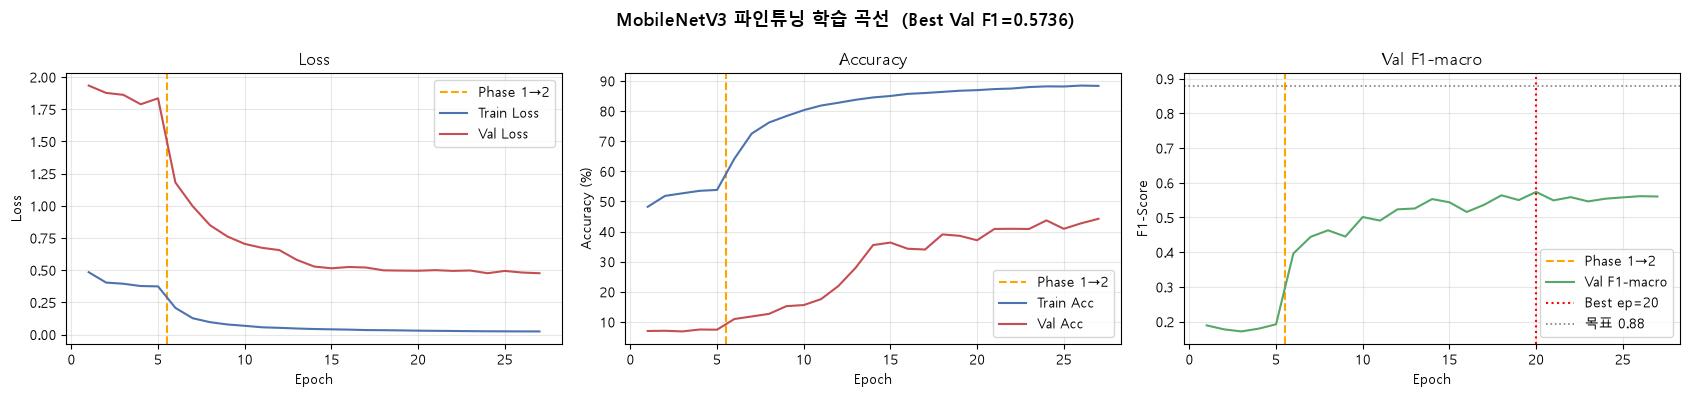

저장 완료: analysis\MobileNetV3_finetune_curves.png


In [8]:
def plot_finetune_curves(history, model_name, best_val_f1):
    epochs = list(range(1, len(history['train_loss']) + 1))
    phase_boundary = history['phase'].index(2)  # Phase 2 시작 인덱스

    fig, axes = plt.subplots(1, 3, figsize=(17, 4))
    fig.suptitle(f'{model_name} 파인튜닝 학습 곡선  (Best Val F1={best_val_f1:.4f})',
                 fontsize=13, fontweight='bold')

    for ax in axes:
        ax.axvline(phase_boundary + 0.5, color='orange', linestyle='--',
                   linewidth=1.5, label='Phase 1→2')

    # Loss
    axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='#4C72B0')
    axes[0].plot(epochs, history['val_loss'],   label='Val Loss',   color='#C44E52')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

    # Accuracy
    axes[1].plot(epochs, [v*100 for v in history['train_acc']], label='Train Acc', color='#4C72B0')
    axes[1].plot(epochs, [v*100 for v in history['val_acc']],   label='Val Acc',   color='#C44E52')
    axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')

    # F1
    best_ep = int(np.argmax(history['val_f1'])) + 1
    axes[2].plot(epochs, history['val_f1'], label='Val F1-macro', color='#55A868')
    axes[2].axvline(best_ep, color='red', linestyle=':', linewidth=1.5,
                    label=f'Best ep={best_ep}')
    axes[2].axhline(0.88, color='gray', linestyle=':', linewidth=1.2, label='목표 0.88')
    axes[2].set_title('Val F1-macro'); axes[2].legend(); axes[2].grid(alpha=0.3)
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('F1-Score')

    plt.tight_layout()
    save_path = ANALYSIS_DIR / f'{model_name}_finetune_curves.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'저장 완료: {save_path}')


plot_finetune_curves(mv3_history, 'MobileNetV3', mv3_best_f1)

## 7. EfficientNet-B0 비교 실험

- timm `in_chans=1` — 첫 번째 Conv 자동 조정
- Phase 1: `model.classifier`만 학습 (나머지 동결)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

EfficientNet-B0  총 파라미터: 4.02M
출력 shape: (2, 9)  ✓
[Phase 1] 백본 동결  |  학습 파라미터: 11,529개  |  lr=0.001
  Ep | Tr Loss | Tr Acc | Vl F1
   1 |  1.4518 | 0.3799 | 0.1112
   2 |  0.7177 | 0.4798 | 0.1291
   3 |  0.5732 | 0.5013 | 0.1435
   4 |  0.4976 | 0.5128 | 0.1434
   5 |  0.4752 | 0.5154 | 0.1401

[Phase 2] 전체 Unfreeze  |  학습 파라미터: 4,018,501개  |  lr=0.0001
  Ep |       LR | Tr Loss | Tr Acc | Vl F1  | Best
   1 | 1.00e-04 |  0.2048 | 0.6666 | 0.3596 | BEST
   2 | 9.96e-05 |  0.0920 | 0.7777 | 0.4047 | BEST
   3 | 9.84e-05 |  0.0624 | 0.8261 | 0.4899 | BEST
   4 | 9.65e-05 |  0.0468 | 0.8606 | 0.5130 | BEST
   5 | 9.38e-05 |  0.0384 | 0.8811 | 0.5690 | BEST
   6 | 9.05e-05 |  0.0337 | 0.8921 | 0.5302 | 
   7 | 8.65e-05 |  0.0259 | 0.9037 | 0.5585 | 
   8 | 8.19e-05 |  0.0235 | 0.9123 | 0.6000 | BEST
   9 | 7.68e-05 |  0.0202 | 0.9162 | 0.6293 | BEST
  10 | 7.13e-05 |  0.0185 | 0.9189 | 0.5631 | 
  11 | 6.55e-05 |  0.0179 | 0.9246 | 0.6275 | 
  12 | 5.94e-05 |  0.0148 | 0.9298 | 0.6298 |

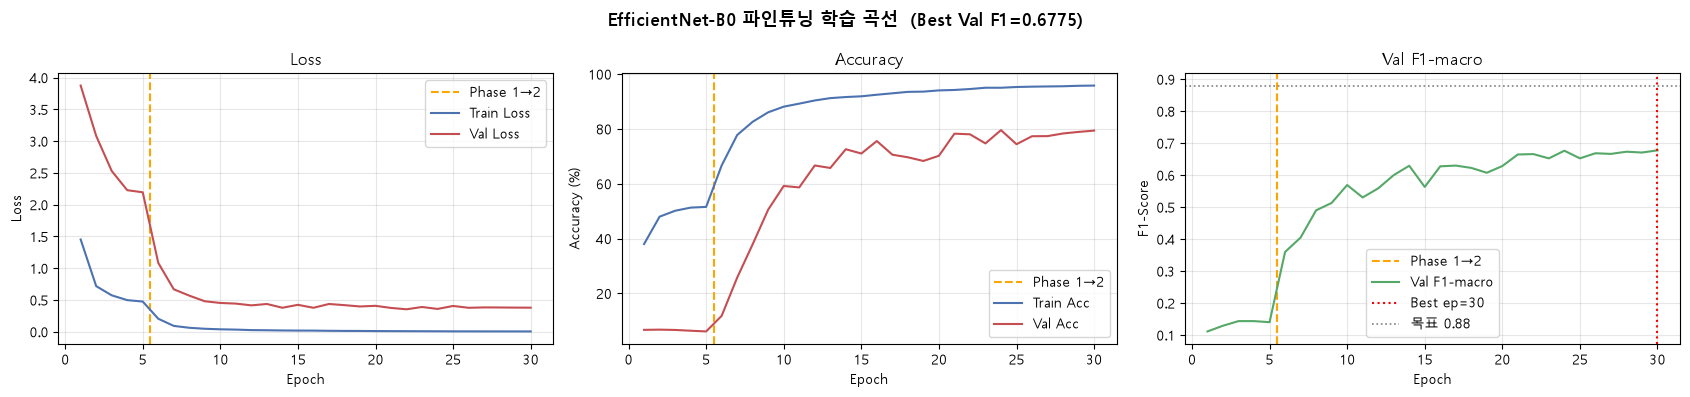

저장 완료: analysis\EfficientNet-B0_finetune_curves.png


In [9]:
eff = build_efficientnet_b0(pretrained=True).to(DEVICE)
total = sum(p.numel() for p in eff.parameters())
print(f'EfficientNet-B0  총 파라미터: {total/1e6:.2f}M')
dummy = torch.zeros(2, 1, 64, 64).to(DEVICE)
print(f'출력 shape: {tuple(eff(dummy).shape)}  ✓')

eff_history, eff_best_f1, eff_ckpt = finetune_model(
    'EfficientNet-B0', eff, DEVICE, train_loader, val_loader, criterion
)
all_results['EfficientNet-B0'] = {
    'history': eff_history, 'best_val_f1': eff_best_f1, 'ckpt': eff_ckpt
}
plot_finetune_curves(eff_history, 'EfficientNet-B0', eff_best_f1)

## 8. ViT-Tiny 비교 실험

- `img_size=64`, `patch_size=16` → 4×4=**16 패치**
- Pretrained positional embedding (196 token) → 16 token으로 **보간** (timm 자동 처리)
- Phase 1: `model.head`만 학습 (Transformer blocks 동결)

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

ViT-Tiny  총 파라미터: 5.39M
(64×64 입력, patch_size=16 → 16개 패치)
출력 shape: (2, 9)  ✓
[Phase 1] 백본 동결  |  학습 파라미터: 1,737개  |  lr=0.001
  Ep | Tr Loss | Tr Acc | Vl F1
   1 |  0.3623 | 0.5406 | 0.2554
   2 |  0.3150 | 0.5771 | 0.2922
   3 |  0.3015 | 0.5850 | 0.2791
   4 |  0.2998 | 0.5898 | 0.2540
   5 |  0.2966 | 0.5919 | 0.2670

[Phase 2] 전체 Unfreeze  |  학습 파라미터: 5,393,289개  |  lr=0.0001
  Ep |       LR | Tr Loss | Tr Acc | Vl F1  | Best
   1 | 1.00e-04 |  0.1523 | 0.7382 | 0.5060 | BEST
   2 | 9.96e-05 |  0.0776 | 0.8026 | 0.4687 | 
   3 | 9.84e-05 |  0.0628 | 0.8242 | 0.5584 | BEST
   4 | 9.65e-05 |  0.0564 | 0.8350 | 0.4958 | 
   5 | 9.38e-05 |  0.0461 | 0.8499 | 0.5252 | 
   6 | 9.05e-05 |  0.0429 | 0.8561 | 0.5553 | 
   7 | 8.65e-05 |  0.0415 | 0.8616 | 0.5520 | 
   8 | 8.19e-05 |  0.0353 | 0.8776 | 0.5681 | BEST
   9 | 7.68e-05 |  0.0331 | 0.8811 | 0.6026 | BEST
  10 | 7.13e-05 |  0.0302 | 0.8849 | 0.5193 | 
  11 | 6.55e-05 |  0.0290 | 0.8843 | 0.5881 | 
  12 | 5.94e-05 |  0.0255 | 0.

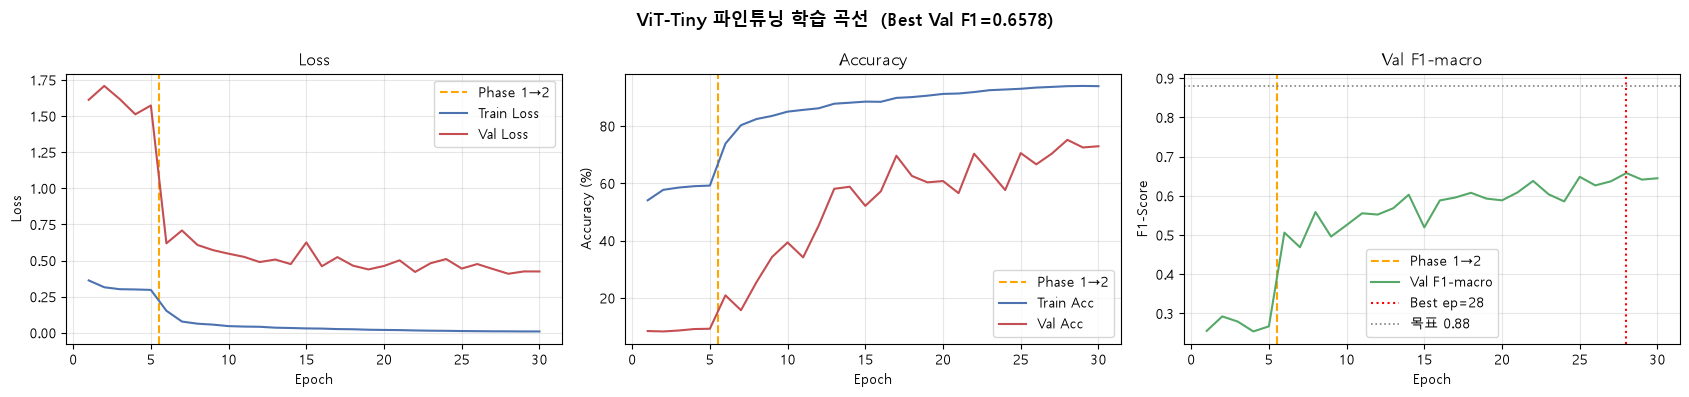

저장 완료: analysis\ViT-Tiny_finetune_curves.png


In [10]:
vit = build_vit_tiny(pretrained=True).to(DEVICE)
total = sum(p.numel() for p in vit.parameters())
print(f'ViT-Tiny  총 파라미터: {total/1e6:.2f}M')
print(f'(64×64 입력, patch_size=16 → {(64//16)**2}개 패치)')
dummy = torch.zeros(2, 1, 64, 64).to(DEVICE)
print(f'출력 shape: {tuple(vit(dummy).shape)}  ✓')

vit_history, vit_best_f1, vit_ckpt = finetune_model(
    'ViT-Tiny', vit, DEVICE, train_loader, val_loader, criterion
)
all_results['ViT-Tiny'] = {
    'history': vit_history, 'best_val_f1': vit_best_f1, 'ckpt': vit_ckpt
}
plot_finetune_curves(vit_history, 'ViT-Tiny', vit_best_f1)

## 9. 모델 성능 비교 (Test Set 최종 평가)

=== 모델 성능 비교 ===
             모델 파라미터 수  Best Val F1 Test Accuracy  Test F1 macro 목표 달성 (F1≥0.88)
    MobileNetV3  1.53M       0.5736        37.19%         0.5618              NO
EfficientNet-B0  4.02M       0.6775        79.37%         0.6673              NO
       ViT-Tiny  5.39M       0.6578        75.57%         0.6473              NO


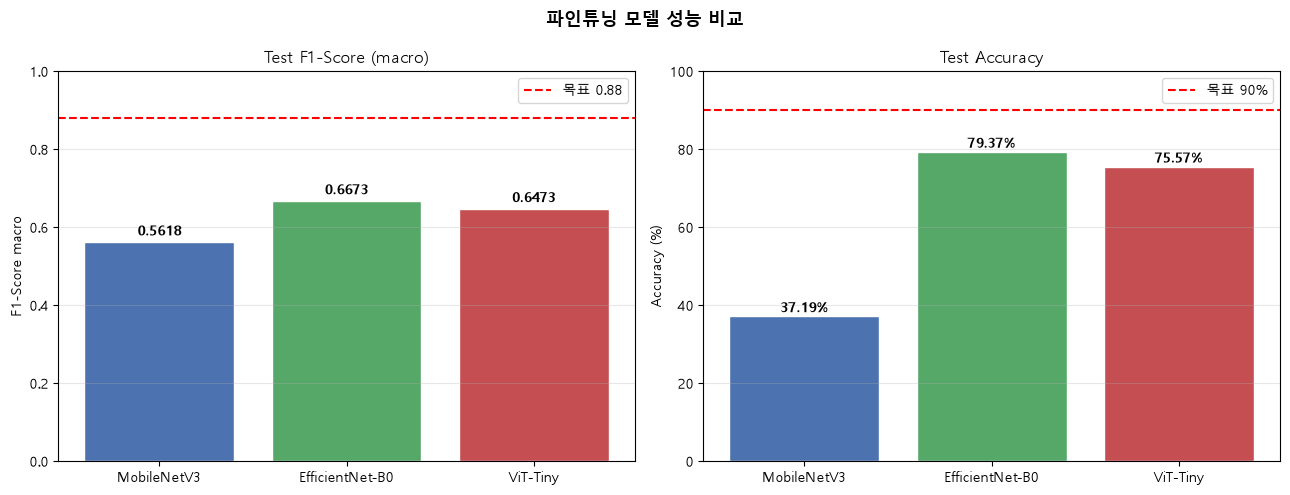

저장 완료: analysis\finetuning_model_comparison.png


In [11]:
BUILD_FNS = {
    'MobileNetV3':    build_mobilenet_v3_small,
    'EfficientNet-B0': build_efficientnet_b0,
    'ViT-Tiny':        build_vit_tiny,
}

comparison_rows = []
for model_name, result in all_results.items():
    m = BUILD_FNS[model_name](pretrained=False).to(DEVICE)
    ckpt = torch.load(result['ckpt'], map_location=DEVICE, weights_only=True)
    m.load_state_dict(ckpt['model_state'])
    _, test_acc, test_f1, test_preds, test_true = eval_epoch(m, test_loader, criterion, DEVICE)

    total_p = sum(p.numel() for p in m.parameters())
    comparison_rows.append({
        '모델':           model_name,
        '파라미터 수':     f'{total_p/1e6:.2f}M',
        'Best Val F1':    round(result['best_val_f1'], 4),
        'Test Accuracy':  f'{test_acc*100:.2f}%',
        'Test F1 macro':  round(test_f1, 4),
        '목표 달성 (F1≥0.88)': 'YES' if test_f1 >= 0.88 else 'NO',
    })
    result['test_acc'] = test_acc
    result['test_f1']  = test_f1

df_comp = pd.DataFrame(comparison_rows)
print('=== 모델 성능 비교 ===')
print(df_comp.to_string(index=False))

# ── 비교 차트
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('파인튜닝 모델 성능 비교', fontsize=13, fontweight='bold')

model_names = df_comp['모델'].tolist()
colors = ['#4C72B0', '#55A868', '#C44E52']

# Test F1
test_f1s = [r['test_f1'] for r in all_results.values()]
bars = axes[0].bar(model_names, test_f1s, color=colors, edgecolor='white')
axes[0].axhline(0.88, color='red', linestyle='--', linewidth=1.5, label='목표 0.88')
axes[0].set_ylabel('F1-Score macro'); axes[0].set_title('Test F1-Score (macro)')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 1.0)
for bar, val in zip(bars, test_f1s):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Test Accuracy
test_accs = [r['test_acc']*100 for r in all_results.values()]
bars2 = axes[1].bar(model_names, test_accs, color=colors, edgecolor='white')
axes[1].axhline(90, color='red', linestyle='--', linewidth=1.5, label='목표 90%')
axes[1].set_ylabel('Accuracy (%)'); axes[1].set_title('Test Accuracy')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, 100)
for bar, val in zip(bars2, test_accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
save_path = ANALYSIS_DIR / 'finetuning_model_comparison.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장 완료: {save_path}')

## 10. 산출물 저장

In [12]:
import json

# 최고 성능 모델 선택
best_model_name = max(all_results, key=lambda k: all_results[k]['test_f1'])
best_result     = all_results[best_model_name]
print(f'최고 성능 모델: {best_model_name}  (Test F1={best_result["test_f1"]:.4f})')

# ── 성능 기록 JSON
results_summary = {
    'best_model': best_model_name,
    'models': {
        name: {
            'best_val_f1':  round(float(r['best_val_f1']), 4),
            'test_accuracy': round(float(r['test_acc']), 4),
            'test_f1_macro': round(float(r['test_f1']), 4),
            'target_met_acc':  bool(r['test_acc'] >= 0.90),
            'target_met_f1':   bool(r['test_f1']  >= 0.88),
            'checkpoint': str(r['ckpt']),
        }
        for name, r in all_results.items()
    },
    'hyperparams': {
        'phase1_epochs': PHASE1_EPOCHS, 'phase1_lr': PHASE1_LR,
        'phase2_epochs': PHASE2_EPOCHS, 'phase2_lr': PHASE2_LR,
        'batch_size': BATCH_SIZE, 'weight_decay': WEIGHT_DECAY,
        'patience': PATIENCE,
    },
}

json_path = ANALYSIS_DIR / 'finetuning_results.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(results_summary, f, ensure_ascii=False, indent=2)
print(f'결과 저장: {json_path}')

# ── 비교 CSV
csv_path = ANALYSIS_DIR / 'finetuning_comparison.csv'
df_comp.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f'비교표 저장: {csv_path}')

print()
print('=== Phase 1 Step 5 완료 ===')
print(f'  최고 모델  : {best_model_name}')
print(f'  Test F1    : {best_result["test_f1"]:.4f}')
print(f'  Test Acc   : {best_result["test_acc"]*100:.2f}%')
print()
print('다음 단계: 06_mlflow_tracking.ipynb  (MLFlow + Optuna 20+ trials)')

최고 성능 모델: EfficientNet-B0  (Test F1=0.6673)
결과 저장: analysis\finetuning_results.json
비교표 저장: analysis\finetuning_comparison.csv

=== Phase 1 Step 5 완료 ===
  최고 모델  : EfficientNet-B0
  Test F1    : 0.6673
  Test Acc   : 79.37%

다음 단계: 06_mlflow_tracking.ipynb  (MLFlow + Optuna 20+ trials)
